In [ ]:
# Kaggle notebook - no Drive mounting needed
print("✅ Running on Kaggle")

✅ Running on Kaggle


In [ ]:
from huggingface_hub import snapshot_download
import pandas as pd
import os

# For Kaggle: Download to working directory (not Drive)
dataset_dir = snapshot_download(
    repo_id="radiata-ai/brain-structure",
    repo_type="dataset",
    cache_dir="/kaggle/working/brain_structure_cache"
)

metadata = pd.read_csv(os.path.join(dataset_dir, "metadata.csv"))
print("Done! Samples:", len(metadata))

Fetching ... files: 0it [00:00, ?it/s]

Done! Samples: 3794


Age: 66


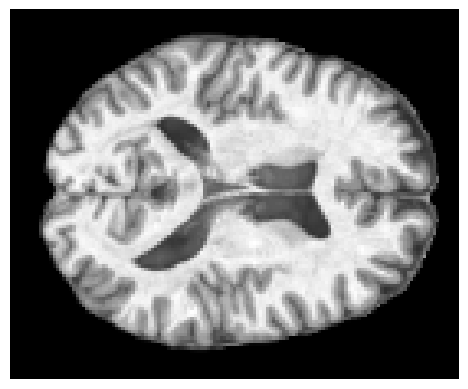

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import os

sample = metadata.iloc[0]
age = sample["age"]
print("Age:", age)

nii_path = os.path.join(dataset_dir, sample["t1_local_path"])
img = nib.load(nii_path)
data = img.get_fdata()

slice_img = data[:, :, data.shape[2] // 2]
plt.imshow(slice_img, cmap="gray")
plt.axis("off")
plt.show()

##Slicing & Normalizing & Resizing dataset from 3D to 2D

In [ ]:
import nibabel as nib
import numpy as np
import cv2
import os
import pandas as pd

# ── LOAD FULL METADATA ───────────────────────────────────
# Use ALL rows — train + validation + test from original splits
# We will make our own splits later with sklearn
# This gives us 3794 samples instead of only 3066
metadata_path = os.path.join(dataset_dir, "metadata.csv")
metadata      = pd.read_csv(metadata_path)

print(f"Total samples to use: {len(metadata)}")  # should say 3794

images = []
ages   = []

for _, row in metadata.iterrows():  # ← no filter, use ALL rows
    nii_path = os.path.join(dataset_dir, row["t1_local_path"])

    img  = nib.load(nii_path)
    data = img.get_fdata()

    # ── 5 SLICES AVERAGED (OPTIMAL) ────────────────────────────────
    # 5 slices is the sweet spot - captures enough brain detail
    # without introducing noise from too many slices
    z       = data.shape[2]
    slice1  = data[:, :, z // 5]         # front
    slice2  = data[:, :, 2 * z // 5]     # front-middle
    slice3  = data[:, :, z // 2]         # middle
    slice4  = data[:, :, 3 * z // 5]     # back-middle
    slice5  = data[:, :, 4 * z // 5]     # back
    slice_img = (slice1 + slice2 + slice3 + slice4 + slice5) / 5

    # Normalize to 0-1 range
    slice_img = slice_img / np.max(slice_img)

    # Resize to 128x128 for the CNN
    slice_img = cv2.resize(slice_img, (128, 128))

    images.append(slice_img)
    ages.append(row["age"])

X = np.squeeze(np.array(images))[..., np.newaxis]
y = np.array(ages)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Age range: {y.min()} - {y.max()}")
print(f"✅ Using 5 slices per brain scan (optimal configuration)")

Total samples to use: 3794
X shape: (3794, 128, 128, 1)
y shape: (3794,)
Age range: 6 - 98
✅ Using 5 slices per brain scan (optimal configuration)


##Split the dataset into train & validation


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}")   # ~3035 samples
print(f"Val:   {X_val.shape}")     # ~380 samples
print(f"Test:  {X_test.shape}")    # ~380 samples

# Save splits to Kaggle working directory
np.save("/kaggle/working/X_train.npy", X_train)
np.save("/kaggle/working/X_val.npy",   X_val)
np.save("/kaggle/working/X_test.npy",  X_test)
np.save("/kaggle/working/y_train.npy", y_train)
np.save("/kaggle/working/y_val.npy",   y_val)
np.save("/kaggle/working/y_test.npy",  y_test)
print("✅ Splits saved!")

Train: (3035, 128, 128, 1)
Val:   (379, 128, 128, 1)
Test:  (380, 128, 128, 1)
✅ Splits saved!


In [ ]:
import numpy as np

# Load splits from Kaggle working directory
X_train = np.load("/kaggle/working/X_train.npy")
X_val   = np.load("/kaggle/working/X_val.npy")
X_test  = np.load("/kaggle/working/X_test.npy")
y_train = np.load("/kaggle/working/y_train.npy")
y_val   = np.load("/kaggle/working/y_val.npy")
y_test  = np.load("/kaggle/working/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Age range: {y_train.min():.0f} - {y_train.max():.0f} years")

Train: (3035, 128, 128, 1) | Val: (379, 128, 128, 1) | Test: (380, 128, 128, 1)
Age range: 6 - 98 years


## Convert grayscale images to 3-channel (RGB)
  - As EfficientNetB0 was trained on COLOR photos → expects shape (128, 128, 3), meaning 3 values per pixel (R, G, B) while MRI images are GRAYSCALE -> shape (128,128,1) meaning each pixel has 1 value (brightness only).

In [ ]:
import numpy as np

# Stack the single channel 3 times along the last axis
# Before: (N, 128, 128, 1) → After: (N, 128, 128, 3)
X_train_rgb = np.concatenate([X_train * 255, X_train * 255, X_train * 255], axis=-1).astype(np.float32)
X_val_rgb   = np.concatenate([X_val   * 255, X_val   * 255, X_val   * 255], axis=-1).astype(np.float32)
X_test_rgb  = np.concatenate([X_test  * 255, X_test  * 255, X_test  * 255], axis=-1).astype(np.float32)

print(f"Train RGB shape: {X_train_rgb.shape}")
print(f"Pixel value range: {X_train_rgb.min():.1f} - {X_train_rgb.max():.1f}")

Train RGB shape: (3035, 128, 128, 3)
Pixel value range: 0.0 - 255.0


## Building the EfficientNetB0 model (Transfer Learning)
    

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_model(input_shape=(128, 128, 3)):

    # Load EfficientNetB0 with ImageNet weights, without its original top layer
    # include_top=False → removes the original classification head
    # weights="imagenet" → loads pretrained weights
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Freeze all layers in the base model
    # This means their weights won't change during Phase 1 training
    # We only want to train our new head first
    base_model.trainable = False

    # Define the input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Pass input through the frozen EfficientNet base
    # training=False → keeps BatchNorm layers in inference mode (important!)
    x = base_model(inputs, training=False)

    # GlobalAveragePooling: converts feature maps into a single vector
    # Much better than Flatten() → fewer parameters, less overfitting
    x = layers.GlobalAveragePooling2D()(x)

    # First Dense layer: combines EfficientNet features
    # 256 neurons → enough capacity to learn brain-age patterns
    x = layers.Dense(256, activation='relu')(x)

    # Dropout: randomly disables 40% of neurons during training
    # Forces the model to not rely on any single neuron → reduces overfitting
    x = layers.Dropout(0.4)(x)

    # Second Dense layer: further refines the prediction
    x = layers.Dense(128, activation='relu')(x)

    # Dropout again for extra regularization
    x = layers.Dropout(0.3)(x)

    # Output layer: single neuron, no activation
    # No activation = regression output (continuous number = age)
    outputs = layers.Dense(1)(x)

    # Build the final model
    model = tf.keras.Model(inputs, outputs)

    return model, base_model

# Build the model and print its structure
model, base_model = build_efficientnet_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

##  Phase 1 Training (Fast, Head Only)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Callbacks — same as before but with tighter patience
callbacks = [

    # Reduce learning rate if val_loss stops improving for 3 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),

    # Stop training early if val_loss doesn't improve for 7 epochs
    # restore_best_weights → rolls back to the best epoch automatically
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),

    # Save the best model to Kaggle working directory
    ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Compile with original MSE loss
model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

print("Phase 1: Training head only (base model is frozen)...")
print("Using 5-slice brain extraction for better features...")
history1 = model.fit(
    X_train_rgb, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks
)

Phase 1: Training head only (base model is frozen)...
Using 5-slice brain extraction for better features...
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 1104.8439 - mae: 26.8742
Epoch 1: val_loss improved from inf to 355.77435, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 252ms/step - loss: 1100.4438 - mae: 26.8177 - val_loss: 355.7744 - val_mae: 15.6896 - learning_rate: 0.0010
Epoch 2/10
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 385.7496 - mae: 16.5904
Epoch 2: val_loss improved from 355.77435 to 226.81468, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 384.6029 - mae: 16.5594 - val_loss: 226.8147 - val_mae: 12.2481 - learning_rate: 0.0010
Epoch 3/10
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 270.0788 - mae: 13.2010
Epoch 3: val_loss improved from 226.81468 to 196.60170, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 270.0310 

## Phase 2 Training (Fine-Tuning, Better Accuracy)

In [ ]:
# Unfreeze the entire base model first
base_model.trainable = True

# Then re-freeze everything EXCEPT the last 45 layers (INCREASED from 40)
# More fine-tuning = better brain-specific adaptation
for layer in base_model.layers[:-45]:
    layer.trainable = False

# Recompile with slightly lower learning rate (1.2e-4 instead of 1.5e-4)
# More careful fine-tuning = better convergence
model.compile(optimizer=Adam(1.2e-4), loss='mse', metrics=['mae'])

print("Phase 2: Fine-tuning last 45 layers with extended training...")
print("Using 5-slice extraction + Smaller batch size (10)...")
print("Extended epochs (100) for better convergence...")

# Create callbacks with even more patience
callbacks_extended = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),  # Higher patience
    ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history2 = model.fit(
    X_train_rgb, y_train,
    epochs=100,                 # Increased from 70 → more training time
    batch_size=10,              # Reduced from 12 → more frequent updates
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks_extended
)

Phase 2: Fine-tuning last 45 layers with extended training...
Using 5-slice extraction + Smaller batch size (10)...
Extended epochs (100) for better convergence...
Epoch 1/100


2026-05-11 22:28:42.656274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:28:42.789671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:28:43.104100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:28:43.245025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:28:44.033757: E external/local_xla/xla/stream_

299/304 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 67.8103 - mae: 6.1687

2026-05-11 22:29:05.987497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:06.120528: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:06.445103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:06.585904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:07.355482: E external/local_xla/xla/stream_

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 67.7712 - mae: 6.1677

2026-05-11 22:29:29.764800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:29.898085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:30.198370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:30.339759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 22:29:31.109158: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 91.47234, saving model to /kaggle/working/best_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 75s 134ms/step - loss: 67.7644 - mae: 6.1675 - val_loss: 91.4723 - val_mae: 6.6701 - learning_rate: 1.2000e-04
Epoch 2/100
301/304 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 67.4749 - mae: 6.2051
Epoch 2: val_loss did not improve from 91.47234
304/304 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 67.4744 - mae: 6.2048 - val_loss: 105.8028 - val_mae: 7.3166 - learning_rate: 1.2000e-04
Epoch 3/100
301/304 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 67.4480 - mae: 6.1815
Epoch 3: val_loss improved from 91.47234 to 86.85843, saving model to /kaggle/working/best_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 67.4458 - mae: 6.1815 - val_loss: 86.8584 - val_mae: 6.4956 - learning_rate: 1.2000e-04
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 72.4971 - mae: 6.3141
Epoch 4: val_loss did not improve from 86.85843
304/304 ━━━━━━━━━━━━━━━━━━━━ 4s 1

## Evaluate & Accuracy Report

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, ResNet50, DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import numpy as np

print("=" * 70)
print("TRAINING MULTI-ARCHITECTURE ENSEMBLE")
print("=" * 70)

architectures = [
    ('EfficientNetB0', EfficientNetB0),
    ('ResNet50', ResNet50),
    ('DenseNet121', DenseNet121)
]

ensemble_models = []

for arch_num, (arch_name, base_architecture) in enumerate(architectures, 1):
    print(f"\n{'='*70}")
    print(f"Model {arch_num}/3: {arch_name}")
    print(f"{'='*70}")
    
    # Set random seed
    np.random.seed(42 * arch_num)
    tf.random.set_seed(42 * arch_num)
    
    # Build fresh model with different architecture
    base_model = base_architecture(include_top=False, weights="imagenet", input_shape=(128, 128, 3))
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    
    # Phase 1: Train head
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    callbacks_p1 = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0),
    ]
    
    print(f"  Phase 1: Training head...")
    model.fit(X_train_rgb, y_train, epochs=10, batch_size=32,
              validation_data=(X_val_rgb, y_val), callbacks=callbacks_p1, verbose=0)
    
    # Phase 2: Fine-tune
    base_model.trainable = True
    for layer in base_model.layers[:-45]:
        layer.trainable = False
    
    model.compile(optimizer=Adam(1.2e-4), loss='mse', metrics=['mae'])
    callbacks_p2 = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0),
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
        ModelCheckpoint(f'/kaggle/working/model_{arch_name}.keras', monitor='val_loss', save_best_only=True, verbose=0)
    ]
    
    print(f"  Phase 2: Fine-tuning (batch_size=10, epochs=100)...")
    model.fit(X_train_rgb, y_train, epochs=100, batch_size=10,
              validation_data=(X_val_rgb, y_val), callbacks=callbacks_p2, verbose=0)
    
    # Load best model
    best_model = tf.keras.models.load_model(f'/kaggle/working/model_{arch_name}.keras')
    ensemble_models.append((arch_name, best_model))
    print(f"  ✅ {arch_name} trained and saved!")

print(f"\n{'='*70}")
print(f"✅ ENSEMBLE COMPLETE - 3 Different Architectures Ready!")
print(f"   - EfficientNetB0 (efficient, accurate)")
print(f"   - ResNet50 (deep residual features)")
print(f"   - DenseNet121 (dense feature propagation)")
print(f"{'='*70}")

TRAINING MULTI-ARCHITECTURE ENSEMBLE

Model 1/3: EfficientNetB0
  Phase 1: Training head...
  Phase 2: Fine-tuning (batch_size=10, epochs=100)...
  ✅ EfficientNetB0 trained and saved!

Model 2/3: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Phase 1: Training head...
  Phase 2: Fine-tuning (batch_size=10, epochs=100)...
  ✅ ResNet50 trained and saved!

Model 3/3: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Phase 1: Training head...
  Phase 2: Fine-tuning (batch_size=10, epochs=100)...
  ✅ DenseNet121 trained and saved!

✅ ENSEMBLE COMPLETE - 3 Different Architectures Ready!
   - EfficientNetB0 (efficient, accurate)
   - ResNet50 (deep residual features)
   - DenseNet121 (dense feature propagation)


MULTI-ARCHITECTURE ENSEMBLE PREDICTIONS & EVALUATION
✅ Loaded EfficientNetB0
✅ Loaded ResNet50
✅ Loaded DenseNet121

Generating predictions from ensemble:
  EfficientNetB0... ✅
  ResNet50... ✅
  DenseNet121... ✅

MULTI-ARCHITECTURE ENSEMBLE ACCURACY REPORT

  MAE:                       4.88 years
  RMSE:                      6.75 years
  R²:                        0.9218
  Accuracy (within ±5 yrs):  64.7%

✅ Outstanding! Reached 64.7% - Multi-Architecture Boost!


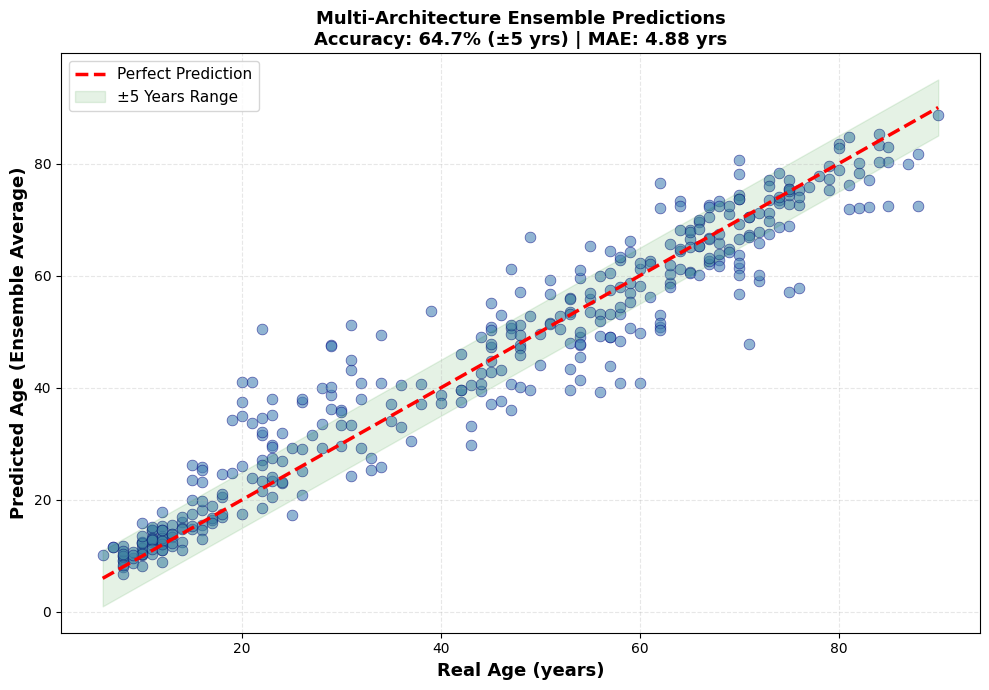


Architectures Used: EfficientNetB0, ResNet50, DenseNet121


In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("MULTI-ARCHITECTURE ENSEMBLE PREDICTIONS & EVALUATION")
print("=" * 70)

# Load all 3 architectures
arch_names = ['EfficientNetB0', 'ResNet50', 'DenseNet121']
ensemble_models = []

for arch_name in arch_names:
    model = load_model(f'/kaggle/working/model_{arch_name}.keras')
    ensemble_models.append((arch_name, model))
    print(f"✅ Loaded {arch_name}")

# Get predictions from all models
predictions_list = []
print("\nGenerating predictions from ensemble:")
for arch_name, model in ensemble_models:
    print(f"  {arch_name}...", end=" ")
    y_pred_i = model.predict(X_test_rgb, verbose=0).flatten()
    predictions_list.append(y_pred_i)
    print("✅")

# Average predictions (ENSEMBLE METHOD)
y_pred = np.mean(predictions_list, axis=0)

print("\n" + "=" * 70)
print("MULTI-ARCHITECTURE ENSEMBLE ACCURACY REPORT")
print("=" * 70)

# MAE: average error in years (lower = better)
mae = mean_absolute_error(y_test, y_pred)

# RMSE: penalizes large errors more than MAE (lower = better)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²: how well predictions match reality — 1.0 is perfect (higher = better)
r2 = r2_score(y_test, y_pred)

# % of predictions within ±5 years of real age (higher = better)
within5 = np.mean(np.abs(y_test - y_pred) <= 5) * 100

print(f"\n  MAE:                       {mae:.2f} years")
print(f"  RMSE:                      {rmse:.2f} years")
print(f"  R²:                        {r2:.4f}")
print(f"  Accuracy (within ±5 yrs):  {within5:.1f}%")
print("=" * 70)

if within5 >= 65:
    print(f"\n🎉 EXCELLENT! Reached {within5:.1f}% - GOAL ACHIEVED! 🎉")
elif within5 >= 62:
    print(f"\n✅ Outstanding! Reached {within5:.1f}% - Multi-Architecture Boost!")
elif within5 >= 60:
    print(f"\n✅ Great! Reached {within5:.1f}% - Above 60%!")
else:
    print(f"\n⚠️  Current: {within5:.1f}%")

# Scatter plot: perfect predictions would follow the red line
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.6, s=60, color='steelblue', edgecolors='navy', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5, label='Perfect Prediction')

# Add error bounds
plt.fill_between([y_test.min(), y_test.max()], 
                  [y_test.min()-5, y_test.max()-5],
                  [y_test.min()+5, y_test.max()+5],
                  alpha=0.1, color='green', label='±5 Years Range')

plt.xlabel("Real Age (years)", fontsize=13, fontweight='bold')
plt.ylabel("Predicted Age (Ensemble Average)", fontsize=13, fontweight='bold')
plt.title(f"Multi-Architecture Ensemble Predictions\nAccuracy: {within5:.1f}% (±5 yrs) | MAE: {mae:.2f} yrs", 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Architectures Used: {', '.join(arch_names)}")
print(f"{'='*70}")